# Optymalizacja dyspozycji magazynu bateryjnego dla arbitrażu energetycznego i ścinania szczytów

## Streszczenie zarządcze

Obiekt komercyjny przyłączony do sieci eksploatuje baterię litowo-jonową o mocy 2 MW / pojemności 8 MWh obok opomiarowanego obciążenia elektrycznego. Obiekt jest rozliczany na dwa sposoby: godzinową **ceną energii** rynku dnia następnego ($/MWh) oraz miesięczną **opłatą mocową** naliczaną od jego pojedynczego najwyższego interwału poboru z sieci ($/MW). Zarządca aktywów musi zdecydować, godzina po godzinie, kiedy ładować baterię (kupując tanią energię i zwiększając pobór z sieci), a kiedy ją rozładowywać (kompensując drogą energię i zmniejszając pobór z sieci). Konkurują ze sobą dwa strumienie wartości: **arbitraż energetyczny** (kupuj tanio w nocy, rozładowuj w wieczornym szczycie) oraz **ścinanie szczytów** (ograniczenie rozliczanego maksimum poboru z sieci). Ładowanie nie jest darmowe — sprawność cyklu w obie strony oznacza, że około 10% zmagazynowanej energii jest tracone — więc harmonogram jest prawdziwą optymalizacją, a nie heurystyką.

Notatnik buduje tę decyzję od początku do końca. Najpierw syntetyzuje realistyczną 24-godzinną krzywą cen rynku dnia następnego (z porannym i wieczornym szczytem oraz nocnym dołkiem) i skorelowany profil obciążenia obiektu, a następnie profiluje oba za pomocą **PROC MEANS** oraz odpornego pasma cenowego 2,5/97,5 percentyla z **PROC UNIVARIATE**. Rdzeniem jest program liniowy w **PROC OPTMODEL**: zmienne decyzyjne dla godzinowego ładowania, rozładowania i stanu naładowania, plus zmienna rozliczanego szczytu, z zastrzeżeniem skumulowanego bilansu stanu naładowania (z oddzielną sprawnością ładowania/rozładowania), ograniczeń mocy i pojemności oraz ograniczenia definiującego szczyt. Funkcja celu maksymalizuje marżę arbitrażu pomniejszoną o opłatę mocową. Następnie **PROC SQL** kwantyfikuje koszt bazowy względem zoptymalizowanego, a trzy panele **PROC SGPLOT** wizualizują harmonogram ładowania/rozładowania na tle ceny, trajektorię stanu naładowania oraz spłaszczony profil poboru z sieci.

**Wynik dla syntetycznego dnia:** optymalizator napełnia baterię w najtańszych godzinach nocnych, rozładowuje ją zarówno w porannym, jak i wieczornym szczycie cenowym, doładowuje w cenowej dolinie w środku dnia i — co kluczowe — powściąga swoją moc ładowania, tak aby nigdy nie utworzyć nowego szczytu poboru z sieci. Dzienny koszt energii spada z **\$2 903,78 do \$2 528,43** — **\$375,34 (12,9%) oszczędności z arbitrażu** — podczas gdy rozliczane maksimum poboru z sieci spada z **3,59 MW do 3,43 MW** (o około **0,16 MW**), co jest warte kolejne **\$18,98** przy założonej dziennej części opłaty mocowej. Ten sam model skaluje się do dłuższych horyzontów, wielu scenariuszy cenowych lub cyklowania uwzględniającego degradację po prostu przez rozszerzenie zbioru indeksów i ograniczeń.

## Źródła danych

Wszystkie dane są **syntetyczne**, generowane w miejscu w pierwszej komórce kodu za pomocą `CALL STREAMINIT(20260605)` dla odtwarzalności. Brak zewnętrznych plików lub dostępu do sieci. Jeden zbiór danych, `price_load`, z 24 godzinowymi wierszami reprezentującymi jeden dzień eksploatacji.

| Zmienna | Typ | Jednostki | Opis |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Godzina dnia eksploatacji (indeks horyzontu) |
| `price` | num | $/MWh | Cena energii rynku dnia następnego: nocny dołek, poranny + wieczorny szczyt, z szumem gaussowskim (z podłogą na $5) |
| `load` | num | MW | Zapotrzebowanie elektryczne obiektu, skorelowane z dzienną aktywnością (z podłogą na 0,3 MW) |
| `day_type` | char | — | Flaga okna taryfowego: `PeakTOU` (godziny 17–21) vs `OffPeak`, używana w podsumowaniu rozpiętości cen szczyt/poza szczytem |

Parametry baterii są stałymi modelu ustalonymi wewnątrz PROC OPTMODEL: 8 MWh użytecznej pojemności, 2 MW maksymalnej mocy ładowania/rozładowania, 0,95 sprawności ładowania i 0,95 sprawności rozładowania (~90% w obie strony), początkowy stan naładowania 0 MWh oraz opłata mocowa \$120/MW naliczana od rozliczanego dziennego szczytu poboru z sieci (dziennie zamortyzowana część miesięcznej opłaty mocowej).

# Optymalizacja dyspozycji magazynu bateryjnego
## Arbitraż energetyczny i ścinanie szczytów dla obiektu przyłączonego do sieci

Obiekt komercyjny eksploatuje **baterię 2 MW / 8 MWh** za swoim licznikiem. Jego rachunek za energię elektryczną ma dwie części: godzinową **cenę energii** ($/MWh) oraz miesięczną **opłatę mocową** od pojedynczego najwyższego interwału poboru z sieci ($/MW). Operator chce godzinowego harmonogramu ładowania/rozładowania, który jednocześnie uchwyci dwa strumienie wartości:

- **Arbitraż** — magazynuj tanią energię nocną, uwalniaj ją w drogich godzinach szczytu.
- **Ścinanie szczytów** — rozładowuj podczas skoku zapotrzebowania, aby obniżyć rozliczane maksimum poboru z sieci.

Ponieważ sprawność cyklu w obie strony traci ~10% zmagazynowanej energii, kompromis jest nietrywialny i uzasadnia prawdziwą optymalizację. Formułujemy go jako program liniowy w **PROC OPTMODEL**, a następnie kwantyfikujemy i wizualizujemy wynik.

> Wszystkie poniższe dane są syntetyczne i generowane w miejscu — notatnik jest w pełni samowystarczalny i uruchamia się w kilka sekund.

## 1. Wygenerowanie syntetycznego profilu ceny rynku dnia następnego i obciążenia

Budujemy jeden dzień eksploatacji (24 godzinowe wiersze). Krzywa cenowa ma nocny dołek oraz poranny + wieczorny szczyt; obciążenie obiektu jest skorelowane z dzienną aktywnością. Ustalone ziarno utrzymuje odtwarzalność przebiegu. Oznaczamy również ustawowe okno szczytu w zależności od pory użytkowania, abyśmy mogli później podsumować rozpiętość szczyt/poza szczytem.

In [1]:
DANE price_load;
    CALL streaminit(20260605);
    DŁUGOŚĆ day_type $13;
    POWTÓRZ hour = 0 TO 23;
        /* Dobowa cena energii ($/MWh): poranny + wieczorny szczyt */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        JEŚLI price < 5 WTEDY price = 5;

        /* Obciążenie obiektu (MW): nocny dołek, wieczorne narastanie */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        JEŚLI LOAD < 0.3 WTEDY LOAD = 0.3;

        JEŚLI hour >= 17 AND hour <= 21 WTEDY day_type = 'Szczyt';
        PRZECIWNIE day_type = 'Poza szczytem';
        WYJŚCIE;
    KONIEC;
    USUŃ BASE;
WYKONAJ;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilowanie rozkładów ceny i obciążenia

Przed optymalizacją sprawdzamy poprawność danych wejściowych. Rozpiętość między najtańszymi a najdroższymi godzinami jest tym, co arbitraż spienięża, a maksymalne obciążenie zakotwicza możliwość ścinania szczytów.

In [2]:
PROCEDURA ŚREDNIE DANE=price_load n mean std MIN MAX maxdec=2;
    ZMIENNA price LOAD;
    ETYKIETA price='Cena energii ($/MWh)' LOAD='Obciążenie (MW)';
WYKONAJ;

                                                  The MEANS Procedure

 Variable  Label                       N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------
 price     Cena energii ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Obciążenie (MW)            24        2.47        0.48        1.71        3.59
 ---------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Rozpiętość cen szczyt vs poza szczytem

Grupowanie według flagi pory użytkowania pokazuje, o ile bogatsze są godziny szczytu w porównaniu z bazą poza szczytem — strukturalny sygnał, który bateria wykorzystuje.

In [3]:
PROCEDURA ŚREDNIE DANE=price_load mean MIN MAX maxdec=2;
    KLASA day_type;
    ZMIENNA price;
    ETYKIETA day_type='Okno taryfowe' price='Cena energii ($/MWh)';
WYKONAJ;

                                                  The MEANS Procedure

                                    Analysis Variable : price Cena energii ($/MWh)

                                                  N
                               Okno taryfowe    Obs       Mean      Minimum      Maximum
                               ---------------------------------------------------------
                               Poza szczytem     19      40.46        18.57        54.89
                               Szczyt             5      68.45        54.88        79.27
                               ---------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Odporne pasmo cenowe (2,5 / 97,5 percentyla)

Charakteryzujemy ogony rozkładu cen pasmem 2,5 / 97,5 percentyla. **PROC UNIVARIATE** z `PCTLPTS=` czysto oblicza dowolne percentyle, co jest właściwym narzędziem dla percentyli ułamkowych.

In [4]:
PROCEDURA UNIVARIATE DANE=price_load NOPRINT;
    ZMIENNA price;
    WYJŚCIE out=price_band pctlpts=2.5 97.5 pctlpre=p_;
WYKONAJ;

PROCEDURA DRUKUJ DANE=price_band noobs ETYKIETA;
    ETYKIETA p_2_5='Cena: 2,5 percentyl' p_97_5='Cena: 97,5 percentyl';
WYKONAJ;


Cena: 2,5 percentyl  Cena: 97,5 percentyl
-------------------  --------------------
              18.57                 79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Optymalizacja dyspozycji (program liniowy)

Wczytujemy godzinową cenę i obciążenie do PROC OPTMODEL i deklarujemy:

- `chg[h]`, `dis[h]` — godzinowa moc ładowania / rozładowania (MW), ograniczona mocą znamionową falownika 2 MW.
- `soc[h]` — stan naładowania (MWh), ograniczony użyteczną pojemnością 8 MWh.
- `peak` — rozliczane maksimum poboru z sieci (MW).

**Ograniczenia.** `soc_balance` akumuluje energię netto w każdej godzinie z oddzielną sprawnością ładowania/rozładowania (postać sumy bieżącej godzinowej rekurencji). `peak_def` wymusza, aby `peak` dominowało nad poborem z sieci netto w każdej godzinie, tak że jego minimalizacja ścina opłatę mocową.

**Funkcja celu.** Maksymalizuj marżę arbitrażu — `price × (discharge − charge)` sumowaną w ciągu dnia — pomniejszoną o opłatę mocową od rozliczanego szczytu. Rozwiązujemy jako ciągły LP.

In [5]:
PROCEDURA optmodel;
    USTAW HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DANE price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Bateria: 8 MWh użytecznej pojemnosci, 2 MW mocy, ~90% sprawności w obie strony */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Opłata mocowa naliczana od rozliczanego szczytu poboru z sieci ($/MW).
       Komercyjne opłaty mocowe są miesięczne; 120 to krańcowa wartosc
       ścinania dzisiejszego maksimum poboru po zamortyzowaniu miesięcznej
       opłaty na dzien. Jest na tyle duza, ze optymalizator powściągnie moc
       ładowania, zamiast tworzyć nowy, wyższy szczyt. */
    num demand_chg = 120;

    /* Zmienne decyzyjne (MW ładowanie / rozładowanie, MWh stan naładowania) */
    ZMIENNA chg{HOURS}  >= 0 <= p_max;
    ZMIENNA dis{HOURS}  >= 0 <= p_max;
    ZMIENNA soc{HOURS}  >= 0 <= capacity;
    ZMIENNA peak        >= 0;   /* rozliczany szczyt poboru z sieci (MW) */

    /* Pobór z sieci netto po działaniu baterii (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Skumulowany stan naładowania: energia wejściowa minus wyjściowa do godziny h,
       ze sprawnościa ladowania/rozladowania. Równoważne rekurencji godzinowej,
       ale zapisane jako suma bieżąca po wcześniejszych godzinach. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Ścinanie szczytów: rozliczany szczyt to max poboru z sieci w ciagu dnia */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maksymalizuj marżę arbitrażu energetycznego netto po oplacie mocowej */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE DANE dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Optymalny harmonogram godzinowy

Rozwiązana tabela pokazuje ładowanie rozłożone na tanie godziny nocne i południowe — moderowane do około 1,0–1,7 MW, tak aby nigdy nie ustanowić nowego szczytu poboru z sieci — rozładowanie skoncentrowane w porannym i wieczornym szczycie cenowym oraz stan naładowania kreślący sensowny cykl napełniania i uwalniania w ramach limitu 8 MWh. Kolumna `grid_mw` utrzymuje płaski pułap ~3,43 MW przez każdą godzinę ładowania, sygnaturę wiążącego ograniczenia szczytu.

In [6]:
PROCEDURA DRUKUJ DANE=dispatch noobs ETYKIETA;
    ZMIENNA hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ETYKIETA hour='Godzina' price='Cena ($/MWh)' LOAD='Obciążenie (MW)'
          charge_mw='Ładowanie (MW)' discharge_mw='Rozładowanie (MW)'
          soc_mwh='Stan naładowania (MWh)' grid_mw='Pobór z sieci (MW)';
WYKONAJ;


Godzina  Cena ($/MWh)    Obciążenie (MW)   Ładowanie (MW)   Rozładowanie (MW)   Stan naładowania (MWh)   Pobór z sieci (MW)
-------  ------------  -----------------  ---------------  ------------------  -----------------------  -------------------
      0         29.73               1.99        1.4418421                   0                  1.36975            3.4318421
      1         28.03               2.16        1.2718421                   0                    2.578            3.4318421
      2         21.87                  2        1.4318421                   0                  3.93825            3.4318421
      3         18.57               1.71        1.7218421                   0                    5.574            3.4318421
      4         27.62               2.13        1.3018421                   0                  6.81075            3.4318421
      5         36.12               2.18        1.2518421                   0                        8            3.4318421
      6


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Kluczowe wskaźniki (KPI): baza vs optymalizacja

Porównujemy scenariusz bazowy „nic nie rób” (płać cenę za surowe obciążenie w każdej godzinie) ze zoptymalizowaną pozycją w sieci i raportujemy oszczędności z arbitrażu, redukcję rozliczanego szczytu oraz wartość pieniężną tej redukcji przy opłacie mocowej — dwie dźwignie, które napędzają uzasadnienie biznesowe.

In [7]:
PROCEDURA SQL;
    CREATE TABLE kpi AS
    WYBIERZ
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

PROCEDURA DRUKUJ DANE=kpi noobs ETYKIETA;
    ETYKIETA base_energy_cost='Koszt bazowy energii'
          opt_energy_cost='Koszt zoptymalizowany'
          arbitrage_savings='Oszczędności z arbitrażu'
          base_peak_mw='Szczyt bazowy (MW)'
          opt_peak_mw='Szczyt zoptymalizowany (MW)'
          peak_reduction_mw='Redukcja szczytu (MW)'
          demand_charge_savings='Oszczędność opłaty mocowej';
WYKONAJ;

Koszt bazowy energii  Koszt zoptymalizowany     Oszczędności z arbitrażu  Szczyt bazowy (MW)  Szczyt zoptymalizowany (MW)  Redukcja szczytu (MW)      Oszczędność opłaty mocowej
--------------------  ---------------------  ---------------------------  ------------------  ---------------------------  ---------------------  ------------------------------
           2903.7774        2528.4335145526               375.3438854474                3.59                    3.4318421              0.1581579                       18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Harmonogram ładowania / rozładowania na tle ceny

Ładowanie (niebieskie słupki) i rozładowanie (czerwona linia ze znacznikami) dzielą lewą oś megawatów; cena rynku dnia następnego (zielona przerywana) jest odczytywana po prawej. Ładowanie skupia się w tanich godzinach nocnych i południowych, podczas gdy rozładowanie strzela w poranny i wieczorny szczyt cenowy — obraz potwierdza, że optymalizator kupuje tanio i sprzedaje drogo.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


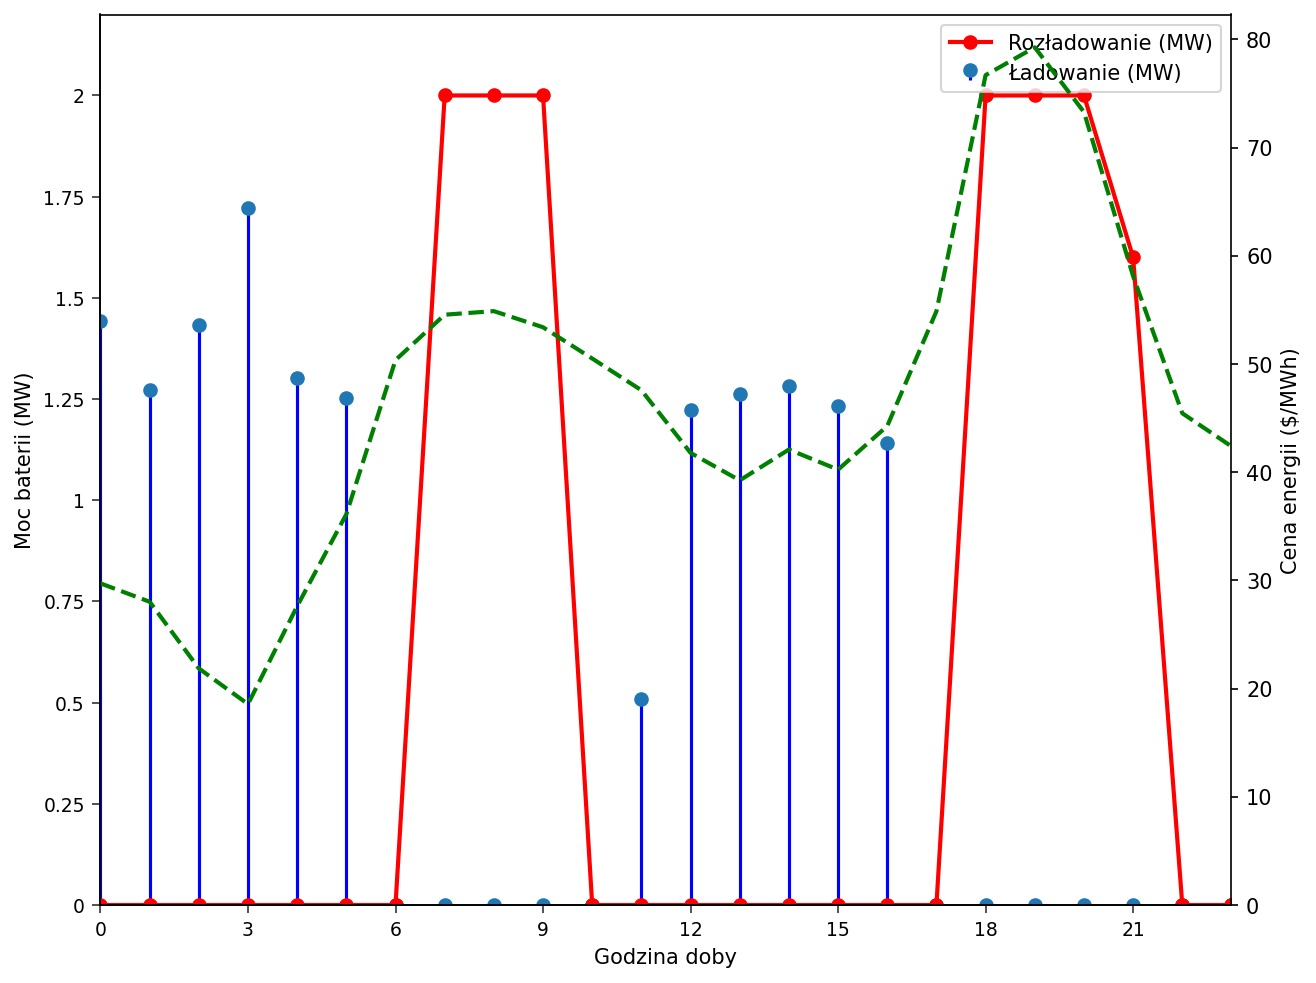

In [8]:
PROCEDURA SGPLOT DANE=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Ładowanie (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Rozładowanie (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Cena ($/MWh)";
    XAXIS ETYKIETA="Godzina doby" VALUES=(0 TO 23 WEDŁUG 3);
    YAXIS ETYKIETA="Moc baterii (MW)" MIN=0 MAX=2.2;
    y2axis ETYKIETA="Cena energii ($/MWh)" MIN=0;
WYKONAJ;

## 9. Trajektoria stanu naładowania

Zmagazynowana energia rośnie, gdy bateria napełnia się w nocy, obniża się w każdym oknie rozładowania i nigdy nie przekracza pułapu użytecznej pojemności 8 MWh (kropkowane odniesienie).


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


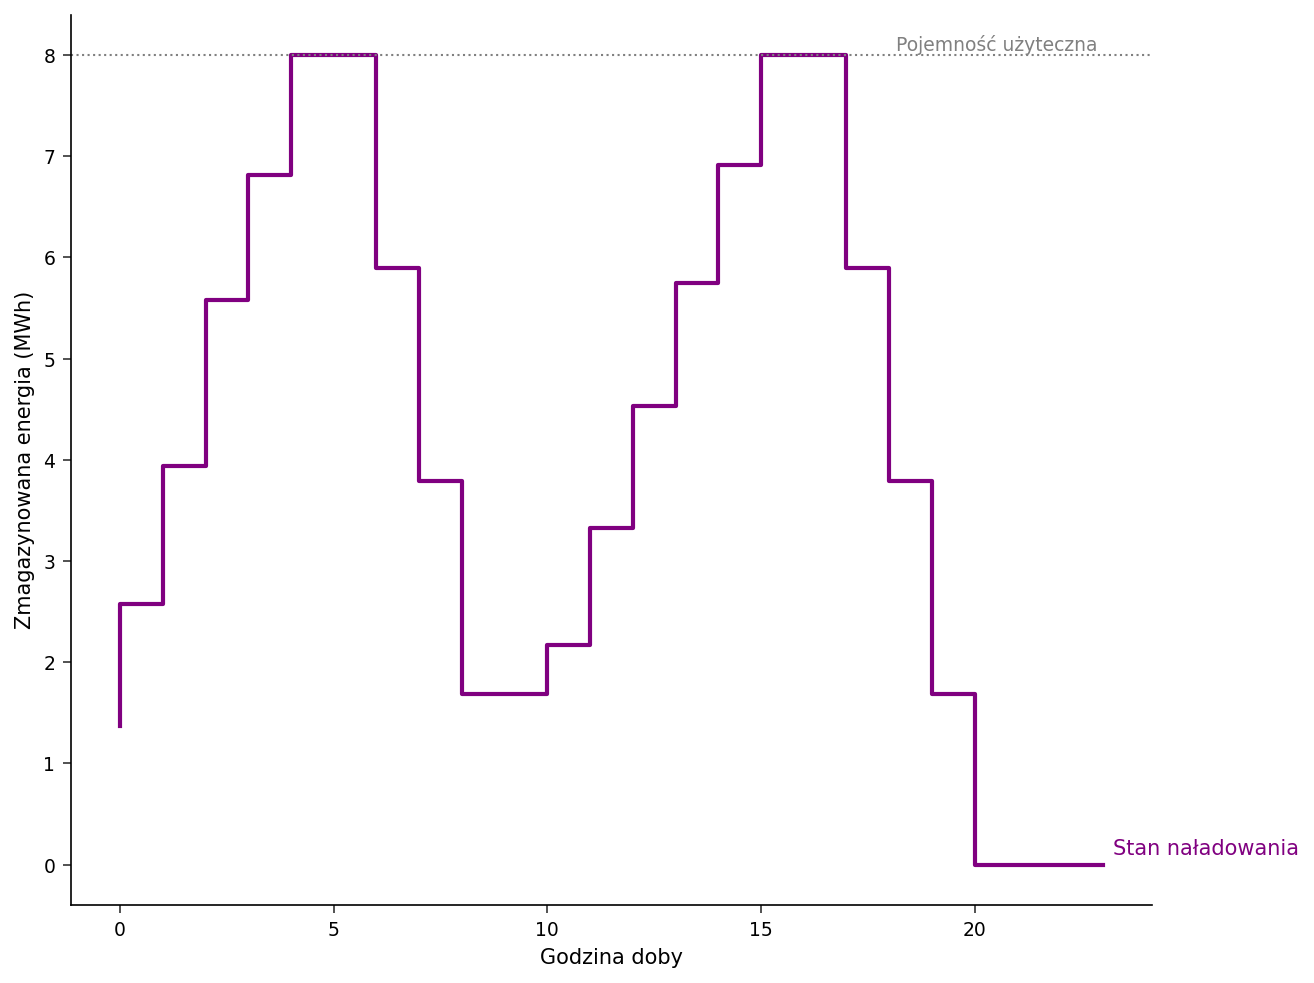

In [9]:
PROCEDURA SGPLOT DANE=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Stan naładowania";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ETYKIETA="Pojemność użyteczna";
    XAXIS ETYKIETA="Godzina doby";
    YAXIS ETYKIETA="Zmagazynowana energia (MWh)";
WYKONAJ;

## 10. Pobór z sieci: przed vs po dyspozycji

Pomarańczowa linia (pobór z sieci z baterią) spada znacznie poniżej przerywanego obciążenia bazowego w wieczornym narastaniu (godziny 18–21) — efekt ścinania szczytów, który obniża opłatę mocową. Podczas nocnych i południowych okien ładowania rośnie, ale optymalizator ogranicza ją do płaskiego pułapu ~3,43 MW, który pozostaje *poniżej* pierwotnego szczytu obciążenia 3,59 MW, tak że ładowanie kupuje tanią energię bez ustanawiania nowego rozliczanego maksimum.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


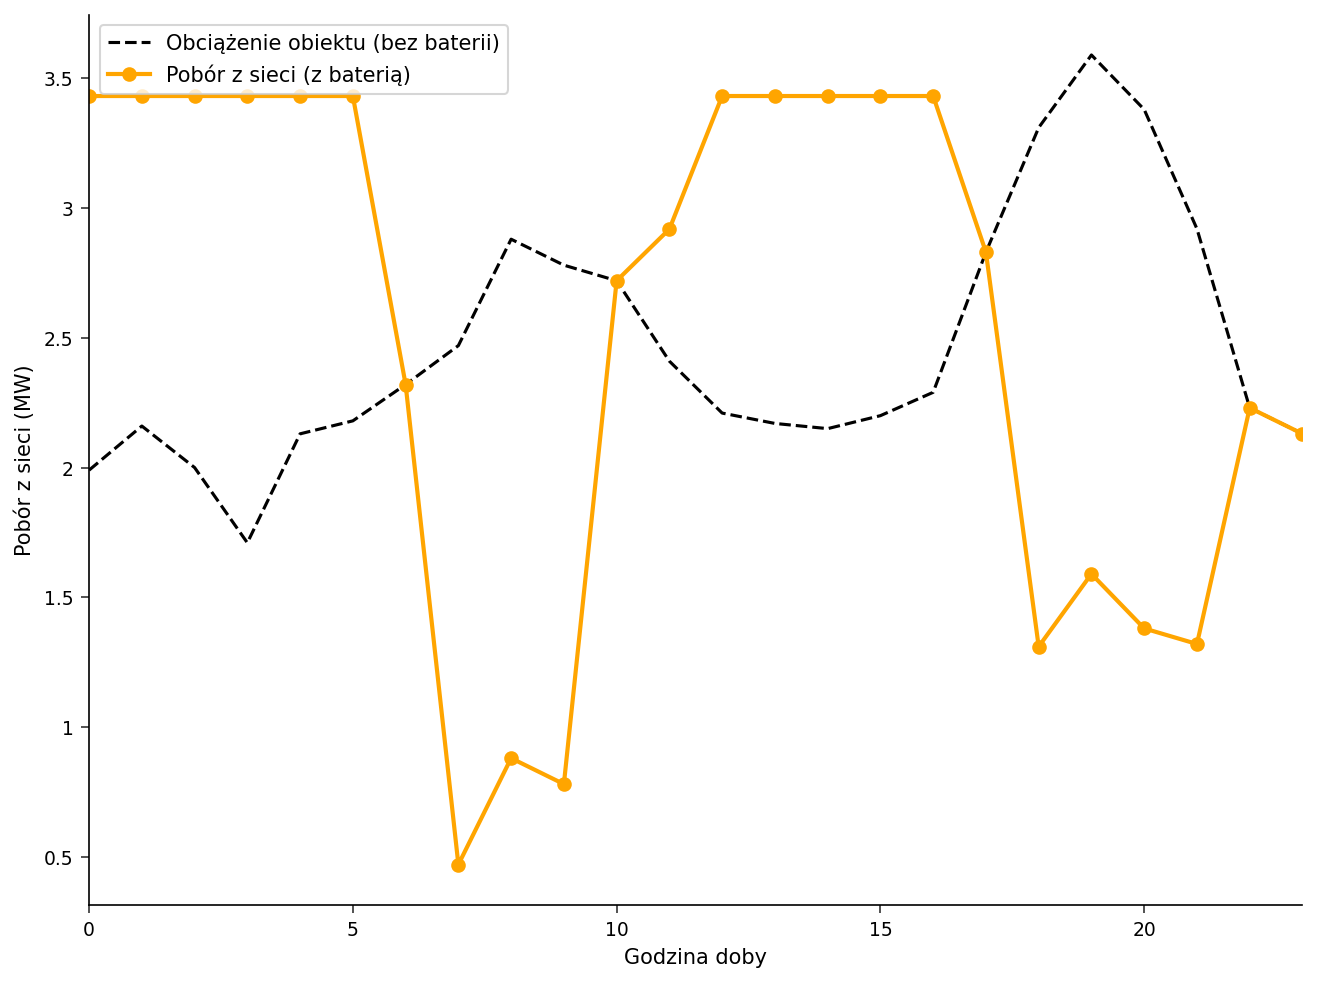

In [10]:
PROCEDURA SGPLOT DANE=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Obciążenie obiektu (bez baterii)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Pobór z sieci (z baterią)";
    XAXIS ETYKIETA="Godzina doby";
    YAXIS ETYKIETA="Pobór z sieci (MW)";
WYKONAJ;

## Interpretacja i kolejne kroki

**Co zdecydował model.** Mimo że sprawność w obie strony obciąża każdy cykl, optymalizator i tak znalazł wyraźną wartość: napełnił baterię w najtańszych godzinach nocnych, rozładował ją w porannym szczycie cenowym (godziny 7–9), doładował w cenowej dolinie w środku dnia (godziny 11–16) i ponownie rozładował w najbogatszym wieczornym szczycie (godziny 18–21). Znamienne, że ładował z mocą tylko 1,0–1,7 MW zamiast pełnej mocy znamionowej 2 MW podczas nocnego napełniania — powściągając moc, tak aby dodatkowy pobór z sieci nigdy nie wypchnął importu powyżej dziennego szczytu obciążenia. Stan naładowania przez cały czas respektował zarówno pojemność 8 MWh, jak i limit mocy 2 MW.

**Uzasadnienie biznesowe.** Dzienny koszt energii spadł z **\$2 903,78 do \$2 528,43** — **\$375,34 (12,9%)** oszczędności z arbitrażu — a rozliczane maksimum poboru z sieci spadło z **3,59 MW do 3,43 MW** (o około **0,16 MW**), obcinając kolejne **\$18,98** z pozycji opłaty mocowej. Zannualizowane w skali dni eksploatacji plus powracająca redukcja opłaty mocowej, jest to rodzaj marży, która uzasadnia inwestycję w magazynowanie.

**Dlaczego LP jest właściwym narzędziem.** Heurystyki („ładuj poniżej ceny mediany, rozładowuj powyżej") ignorują straty sprawności, sprzężenie pojemności między godzinami oraz fakt, że opłata mocowa zależy od pojedynczego interwału — ładowałyby z pełną mocą w nocy i *podniosłyby* rozliczany szczyt, niszcząc wartość ścinania szczytów. PROC OPTMODEL ujmuje to wszystko w jednym deklaratywnym modelu i zwraca dowodliwie optymalny harmonogram, który tutaj celowo moderuje tempo ładowania, aby chronić szczyt.

**Rozszerzanie modelu.**

- **Dłuższe horyzonty / wielodniowe** — poszerz zbiór indeksów `HOURS`; dodaj limity cyklowania międzydobowego.
- **Niepewność cenowa** — rozwiąż LP dla wielu scenariuszy cenowych i uśrednij decyzję pierwszej godziny (krocząca polityka stochastyczna).
- **Degradacja baterii** — dodaj składnik kary za przepustowość lub ograniczenie skumulowanych cykli, aby wymieniać arbitraż na żywotność aktywa.
- **Regulacja częstotliwości / rynki mocy** — wprowadź ograniczenia rezerwowanego zapasu mocy, tak aby bateria mogła nakładać przychody z usług pomocniczych na arbitraż.

Wszystkie te modyfikacje są przyrostowymi edycjami tego samego bloku OPTMODEL — struktura ustanowiona tutaj przechodzi niezmieniona.